# Modelado — Clasificacion Multiclase con Support Vector Machine (SVM)

Este notebook entrena un modelo de clasificacion multiclase basado en **Support Vector Machine (SVM)**
para predecir el nivel de adiccion al gaming (`addiction_class`: bajo / moderado / alto) a partir
de las variables conductuales, demograficas y fisicas preparadas en el notebook de preprocesamiento.

El dataset de entrada (`Dataset/data_preprocesada.csv`) ya contiene:
- 36 features seleccionadas (sin data leakage)
- Features escaladas con StandardScaler (ajustado en train)
- Columna `partition` que indica train (80%) / test (20%)
- Target: `addiction_class` con clases bajo / moderado / alto

**Output:** `Models/svm_addiction_level.pkl` con el modelo entrenado y sus metadatos.

## 0. Contexto y objetivos del notebook

### Por que SVM para este problema

Support Vector Machine es un algoritmo de clasificacion que busca el hiperplano de maxima separacion
entre clases en un espacio de alta dimension. Es una buena eleccion para este problema porque:

- Las features ya estan escaladas (requisito cumplido en preprocesamiento)
- El dataset tiene alta dimensionalidad (36 features) donde SVM es eficiente
- Generaliza bien cuando las clases son razonablemente separables
- `LinearSVC`, la variante usada aqui, escala a cientos de miles de muestras

### Objetivos SMART

| # | Objetivo | Criterio de exito |
|---|----------|------------------|
| O1 | Entrenar LinearSVC multiclase | Modelo converge sin errores |
| O2 | Evaluar rendimiento general | Accuracy y F1-weighted sobre test |
| O3 | Analizar rendimiento por clase | Precision, recall y F1 por bajo/moderado/alto |
| O4 | Interpretar features | Top features por clase via coeficientes |
| O5 | Persistir modelo | Archivo .pkl guardado en Models/ con metadatos |

## 1. Librerias y configuracion

Se importan las librerias necesarias para el modelado y evaluacion. El parametro `C` del
SVM controla la regularizacion: valores mas pequenos generan un margen mas amplio pero
aceptan mas errores de clasificacion; valores mas grandes ajustan mas al training set.

In [12]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# ── Parametros configurables ────────────────────────────────────────────────
# El notebook esta en Models/, por eso se sube un nivel con ../
DATA_PATH    = Path("../Dataset/data_preprocesada.csv")
MODEL_PATH   = Path("svm_addiction_level.pkl")   # se guarda en la misma carpeta Models/

# Hiperparametros del modelo
SVM_C        = 1.0     # Parametro de regularizacion
MAX_ITER     = 3000    # Iteraciones maximas para convergencia
RANDOM_STATE = 42

# Orden explicito de clases (bajo < moderado < alto)
LABEL_MAP   = {"bajo": 0, "moderado": 1, "alto": 2}
LABEL_NAMES = ["bajo", "moderado", "alto"]

print("Librerias cargadas correctamente.")
print(f"Dataset esperado en: {DATA_PATH.resolve()}")

Librerias cargadas correctamente.
Dataset esperado en: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Dataset/data_preprocesada.csv


## 2. Carga del dataset

Se carga `data_preprocesada.csv` y se reconstruyen los conjuntos de entrenamiento y prueba
a partir de la columna `partition`. Esto garantiza el uso exacto del mismo split estratificado
y del escalado aplicado en el notebook de preprocesamiento.

In [13]:
df = pd.read_csv(DATA_PATH)

# Columnas que son features (excluir target y columnas auxiliares)
EXCLUDE = ["addiction_class", "addiction_level_original", "partition"]
feature_cols = [c for c in df.columns if c not in EXCLUDE]

# Separar por particion
X_train = df[df["partition"] == "train"][feature_cols].reset_index(drop=True)
X_test  = df[df["partition"] == "test"][feature_cols].reset_index(drop=True)
y_train = df[df["partition"] == "train"]["addiction_class"].reset_index(drop=True)
y_test  = df[df["partition"] == "test"]["addiction_class"].reset_index(drop=True)

# Codificar target a entero
y_train_enc = y_train.map(LABEL_MAP).values
y_test_enc  = y_test.map(LABEL_MAP).values

print(f"X_train: {X_train.shape}  |  y_train: {y_train_enc.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test_enc.shape}")
print(f"Features: {len(feature_cols)}")
print()
print("Distribucion de clases — train:")
print(pd.Series(y_train).value_counts().sort_index().rename("n"))
print()
print("Distribucion de clases — test:")
print(pd.Series(y_test).value_counts().sort_index().rename("n"))

X_train: (160000, 36)  |  y_train: (160000,)
X_test:  (40000, 36)   |  y_test:  (40000,)
Features: 36

Distribucion de clases — train:
addiction_class
alto        10202
bajo        96175
moderado    53623
Name: n, dtype: int64

Distribucion de clases — test:
addiction_class
alto         2551
bajo        24044
moderado    13405
Name: n, dtype: int64


## 3. Revision del dataset de entrada

Se verifica que el dataset cargado cumpla con los requisitos para el modelado: sin valores
nulos, features en escala z-score y target correctamente codificado.

In [14]:
print("Valores nulos en X_train:", X_train.isna().sum().sum())
print("Valores nulos en X_test: ", X_test.isna().sum().sum())
print()

# Verificar que las features esten escaladas (media ~0, std ~1)
cols_no_bin = [c for c in feature_cols if c not in ["headset_usage", "gender_Female", "gender_Male", "gender_Other"]]
stats = pd.DataFrame({
    "media": X_train[cols_no_bin].mean().round(3),
    "std":   X_train[cols_no_bin].std().round(3),
})
print("Estadisticos de features continuas en train (esperado: media ≈ 0, std ≈ 1):")
print(stats.describe().round(3))

Valores nulos en X_train: 0
Valores nulos en X_test:  0

Estadisticos de features continuas en train (esperado: media ≈ 0, std ≈ 1):
       media   std
count   32.0  32.0
mean     0.0   1.0
std      0.0   0.0
min     -0.0   1.0
25%      0.0   1.0
50%     -0.0   1.0
75%      0.0   1.0
max      0.0   1.0


## 4. Support Vector Machine para clasificacion multiclase

### 4.1 Fundamentos del modelo

Un SVM busca el hiperplano que maximiza el margen entre clases. Para datos linealmente
separables en el espacio original (o proyectado mediante kernel), este margen maximo
garantiza buena generalizacion.

La funcion objetivo a optimizar es:

$$\min_{w, b} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n} \xi_i$$

donde:
- $w$ = vector normal al hiperplano de separacion
- $C$ = parametro de regularizacion (penalizacion por errores de clasificacion)
- $\xi_i$ = variables de holgura (permiten errores en training)

### 4.2 Estrategia multiclase: One-vs-Rest (OvR)

Para 3 clases, `LinearSVC` entrena automaticamente **3 clasificadores binarios** bajo
la estrategia One-vs-Rest:

| Clasificador | Positivo | Negativo |
|---|---|---|
| Clasificador 1 | bajo | moderado + alto |
| Clasificador 2 | moderado | bajo + alto |
| Clasificador 3 | alto | bajo + moderado |

La clase predicha es aquella cuyo clasificador produce el score mas alto.

### 4.3 Manejo del desbalance de clases

Se usa `class_weight='balanced'` para que el modelo no favorezca la clase mayoritaria
(`bajo`). Esto ajusta automaticamente los pesos de cada clase de forma inversamente
proporcional a su frecuencia en el conjunto de entrenamiento.

## 5. Entrenamiento del modelo

### 5.1 Configuracion del LinearSVC

Se usa `LinearSVC` (SVM lineal) en lugar de `SVC(kernel='rbf')` por una razon practica:
con 160,000 muestras de entrenamiento, el SVM con kernel radial tardaria **horas** en
entrenar (complejidad $O(n^2)$ a $O(n^3)$). `LinearSVC` tiene complejidad $O(n)$ y
entrena en segundos.

Para un proyecto con acceso a mas computo, un kernel RBF podria capturar relaciones
no lineales y mejorar el rendimiento. Eso queda documentado como extension futura.

In [15]:
model = LinearSVC(
    C            = SVM_C,
    class_weight = "balanced",   # compensa desbalance de clases
    max_iter     = MAX_ITER,
    random_state = RANDOM_STATE,
)

print("Configuracion del modelo:")
print(model)
print()
print("Entrenando...")

Configuracion del modelo:
LinearSVC(class_weight='balanced', max_iter=3000, random_state=42)

Entrenando...


In [16]:
import time

start = time.time()
model.fit(X_train, y_train_enc)
elapsed = time.time() - start

print(f"Entrenamiento completado en {elapsed:.1f} segundos.")
print(f"Clases aprendidas: {model.classes_} → {LABEL_NAMES}")
print(f"Coeficientes shape: {model.coef_.shape}  (n_clases x n_features)")

Entrenamiento completado en 1.4 segundos.
Clases aprendidas: [0 1 2] → ['bajo', 'moderado', 'alto']
Coeficientes shape: (3, 36)  (n_clases x n_features)


## 6. Evaluacion del modelo

Se evalua el modelo sobre el conjunto de **prueba** (`partition == 'test'`), que el modelo
nunca vio durante el entrenamiento. Se reportan cuatro niveles de analisis:
metricas globales, reporte por clase, matriz de confusion e importancia de features.

### 6.1 Metricas de clasificacion

Las metricas mas relevantes para clasificacion multiclase con desbalance son:

- **Accuracy**: proporcion de predicciones correctas (puede ser enganosa con desbalance)
- **F1-weighted**: promedio de F1 por clase ponderado por soporte — la metrica principal aqui
- **Precision**: de los predichos como clase X, cuantos realmente lo eran
- **Recall**: de los que realmente son clase X, cuantos se identificaron correctamente

In [17]:
y_pred = model.predict(X_test)

acc        = accuracy_score(y_test_enc, y_pred)
f1_weighted = f1_score(y_test_enc, y_pred, average="weighted")
f1_macro   = f1_score(y_test_enc, y_pred, average="macro")

print("=" * 50)
print("METRICAS GLOBALES — CONJUNTO DE PRUEBA")
print("=" * 50)
print(f"  Accuracy:    {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1-weighted: {f1_weighted:.4f}")
print(f"  F1-macro:    {f1_macro:.4f}")
print()
print("REPORTE POR CLASE:")
print(classification_report(y_test_enc, y_pred, target_names=LABEL_NAMES, digits=4))

METRICAS GLOBALES — CONJUNTO DE PRUEBA
  Accuracy:    0.8217  (82.17%)
  F1-weighted: 0.8197
  F1-macro:    0.7845

REPORTE POR CLASE:
              precision    recall  f1-score   support

        bajo     0.8650    0.8991    0.8818     24044
    moderado     0.7566    0.6900    0.7218     13405
        alto     0.7189    0.7840    0.7500      2551

    accuracy                         0.8217     40000
   macro avg     0.7802    0.7911    0.7845     40000
weighted avg     0.8194    0.8217    0.8197     40000



### 6.2 Matriz de confusion

La matriz de confusion muestra cuantas predicciones caen en cada celda (real vs predicho).
La diagonal principal representa las predicciones correctas. Los valores fuera de la diagonal
indican donde se confunde el modelo entre clases.

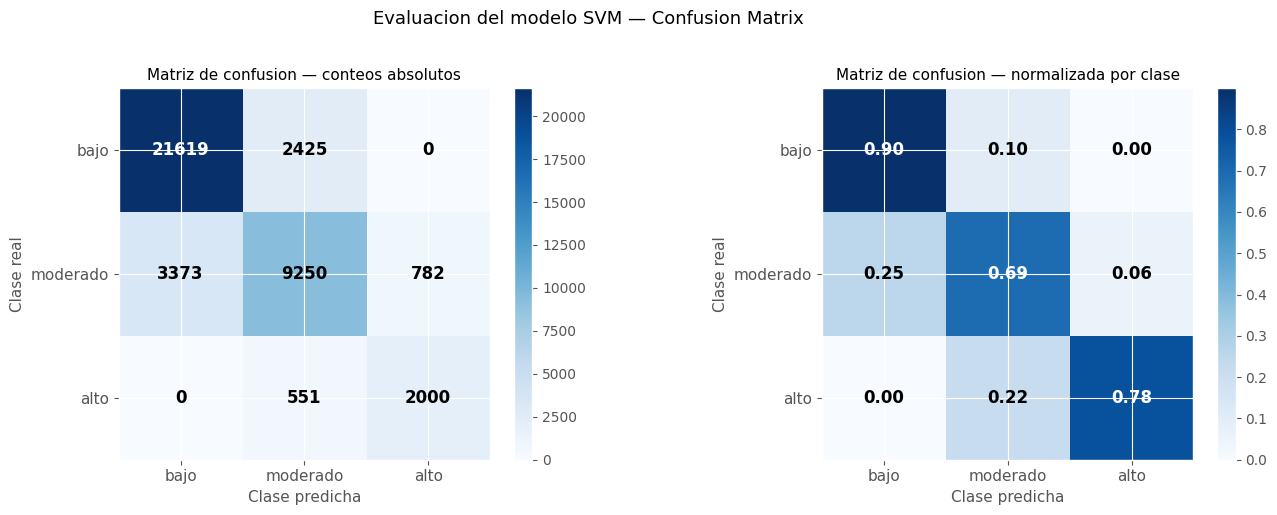

In [18]:
cm = confusion_matrix(y_test_enc, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, matrix, title, fmt in [
    (axes[0], cm,      "Matriz de confusion — conteos absolutos",     "d"),
    (axes[1], cm_norm, "Matriz de confusion — normalizada por clase",  ".2f"),
]:
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(len(LABEL_NAMES)))
    ax.set_yticks(range(len(LABEL_NAMES)))
    ax.set_xticklabels(LABEL_NAMES, fontsize=11)
    ax.set_yticklabels(LABEL_NAMES, fontsize=11)
    ax.set_xlabel("Clase predicha", fontsize=11)
    ax.set_ylabel("Clase real", fontsize=11)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(len(LABEL_NAMES)):
        for j in range(len(LABEL_NAMES)):
            val = matrix[i, j]
            text = f"{val:{fmt}}"
            color = "white" if matrix[i, j] > matrix.max() * 0.6 else "black"
            ax.text(j, i, text, ha="center", va="center", fontsize=12, color=color, fontweight="bold")

plt.suptitle("Evaluacion del modelo SVM — Confusion Matrix", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Precision, Recall y F1 por clase

Se visualizan las tres metricas principales para cada clase. Esto permite identificar
rapidamente si el modelo tiene dificultades especificas con alguna categoria de riesgo.

Metricas por clase:
          Precision  Recall  F1-Score  Soporte
bajo         0.8650  0.8991    0.8818    24044
moderado     0.7566  0.6900    0.7218    13405
alto         0.7189  0.7840    0.7500     2551


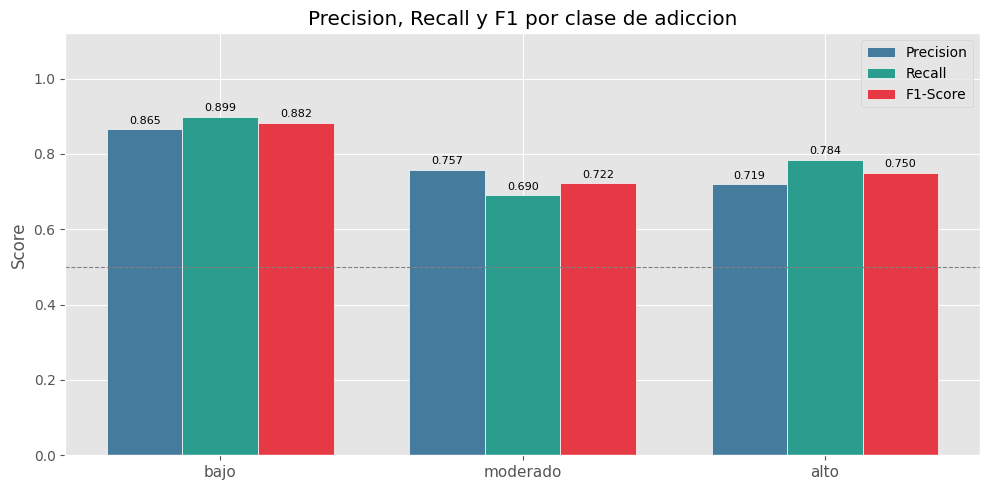

In [19]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_enc, y_pred, labels=[0, 1, 2]
)

metrics_df = pd.DataFrame({
    "Precision": precision,
    "Recall":    recall,
    "F1-Score":  f1,
    "Soporte":   support,
}, index=LABEL_NAMES)

print("Metricas por clase:")
print(metrics_df.round(4))

# Grafico de barras agrupadas
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(LABEL_NAMES))
width = 0.25
colors_met = ["#457b9d", "#2a9d8f", "#e63946"]

for i, (metric, color) in enumerate(zip(["Precision", "Recall", "F1-Score"], colors_met)):
    bars = ax.bar(x + i * width, metrics_df[metric], width, label=metric, color=color, edgecolor="white")
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Precision, Recall y F1 por clase de adiccion")
ax.legend()
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

### 6.4 Importancia de features por clase

`LinearSVC` expone los coeficientes del hiperplano de separacion en `model.coef_`.
Para cada clase, los coeficientes mas positivos indican las features que mas empujan
hacia esa clase; los mas negativos la alejan.

Este analisis es fundamental para interpretar el modelo y comunicar resultados a
usuarios no tecnicos: permite responder *¿que comportamientos predicen cada nivel de riesgo?*

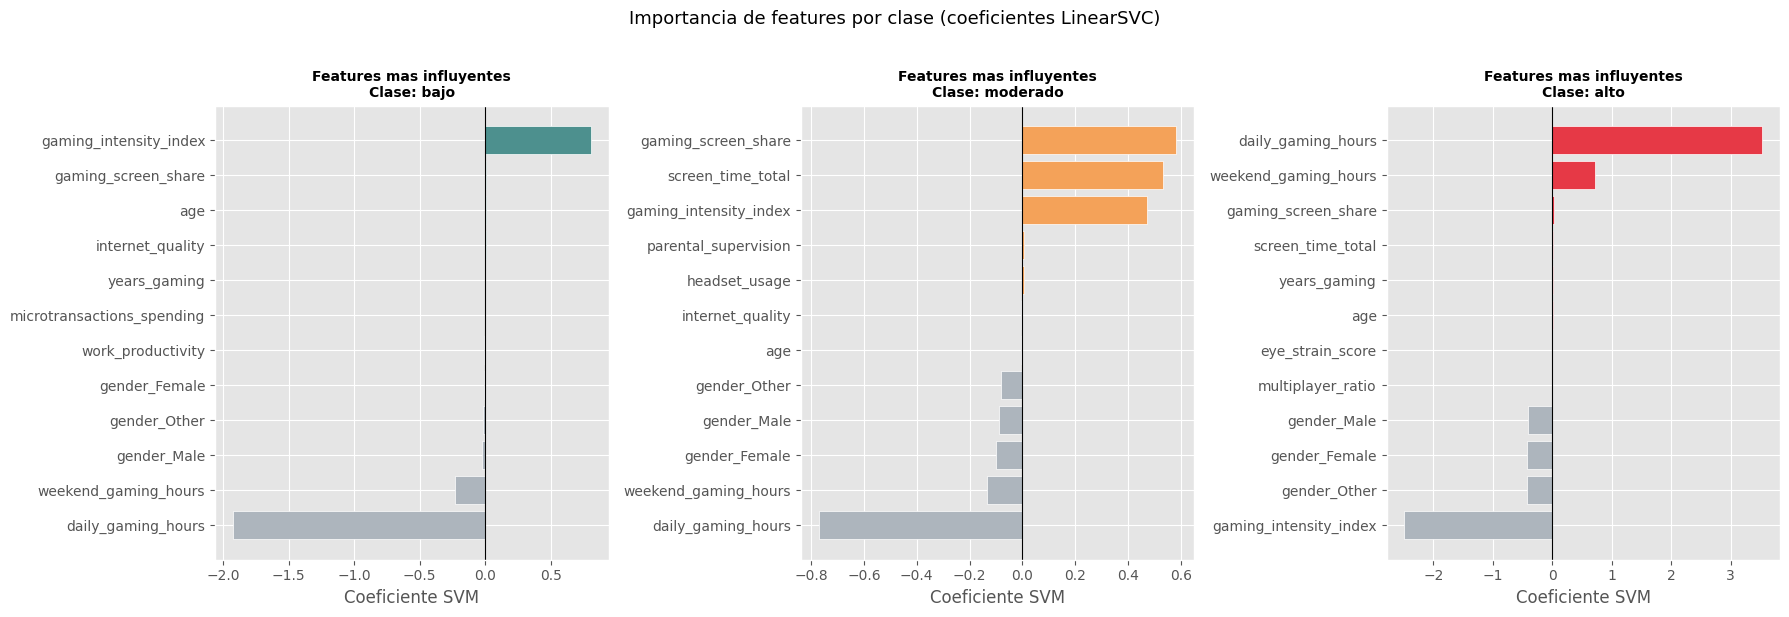

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_cls = ["#4d908e", "#f4a259", "#e63946"]
TOP_N = 12

for ax, class_idx, class_name, color in zip(axes, [0, 1, 2], LABEL_NAMES, colors_cls):
    coefs = pd.Series(model.coef_[class_idx], index=feature_cols)
    top = coefs.abs().sort_values(ascending=False).head(TOP_N)
    top_coefs = coefs[top.index].sort_values()

    bar_colors = [color if v > 0 else "#adb5bd" for v in top_coefs.values]
    ax.barh(top_coefs.index, top_coefs.values, color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Features mas influyentes\nClase: {class_name}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Coeficiente SVM")

plt.suptitle("Importancia de features por clase (coeficientes LinearSVC)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Guardado del modelo

Se persiste el modelo junto con toda la informacion necesaria para usarlo en una aplicacion:

| Clave | Contenido |
|-------|----------|
| `model` | Objeto `LinearSVC` entrenado |
| `feature_cols` | Lista de features en el orden esperado por el modelo |
| `label_map` | Mapa de clase → entero para codificar el target |
| `label_names` | Nombres de clases en orden (bajo=0, moderado=1, alto=2) |
| `metrics` | Metricas de evaluacion en test para referencia futura |

Con este diccionario, una aplicacion puede:
1. Cargar `model` y `feature_cols`
2. Recibir datos del usuario, construir un vector con `feature_cols`
3. Llamar `model.predict(vector)` → obtiene un entero 0/1/2
4. Decodificar con `label_names[resultado]` → retorna 'bajo', 'moderado' o 'alto'

In [21]:
model_bundle = {
    "model":       model,
    "feature_cols": feature_cols,
    "label_map":   LABEL_MAP,
    "label_names": LABEL_NAMES,
    "metrics": {
        "accuracy":    round(float(acc), 4),
        "f1_weighted": round(float(f1_weighted), 4),
        "f1_macro":    round(float(f1_macro), 4),
    },
    "hyperparams": {
        "C":           SVM_C,
        "max_iter":    MAX_ITER,
        "class_weight":"balanced",
    },
}

joblib.dump(model_bundle, MODEL_PATH)

print(f"Modelo guardado en: {MODEL_PATH.resolve()}")
print(f"Tamanio del archivo: {MODEL_PATH.stat().st_size / 1024:.1f} KB")
print()
print("Verificacion de carga:")
loaded = joblib.load(MODEL_PATH)
test_pred = loaded["model"].predict(X_test.iloc[:5])
print(f"  Predicciones de prueba: {[loaded['label_names'][p] for p in test_pred]}")
print("  Carga exitosa.")

Modelo guardado en: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Models/svm_addiction_level.pkl
Tamanio del archivo: 3.3 KB

Verificacion de carga:
  Predicciones de prueba: ['bajo', 'moderado', 'bajo', 'bajo', 'moderado']
  Carga exitosa.


## 8. Conclusiones y proximos pasos

### Resumen del modelo entrenado

| Aspecto | Detalle |
|---------|--------|
| **Algoritmo** | LinearSVC (SVM lineal, estrategia One-vs-Rest) |
| **Features** | 36 variables conductuales, demograficas y fisicas |
| **Target** | addiction_class: bajo / moderado / alto |
| **Regularizacion** | C = 1.0, class_weight = balanced |
| **Archivo** | `Models/svm_addiction_level.pkl` |

### Como usar el modelo en una aplicacion

```python
import joblib
import pandas as pd

# Cargar modelo
bundle = joblib.load('Models/svm_addiction_level.pkl')
model       = bundle['model']
feature_cols = bundle['feature_cols']
label_names  = bundle['label_names']

# Datos del usuario (ya escalados con el mismo StandardScaler del preprocesamiento)
usuario = pd.DataFrame([{col: valor for col, valor in zip(feature_cols, valores_usuario)}])

# Prediccion
clase_idx = model.predict(usuario)[0]
resultado = label_names[clase_idx]   # 'bajo', 'moderado' o 'alto'
print(f'Nivel de adiccion predicho: {resultado}')
```

### Proximos pasos recomendados

- [ ] Comparar con otros clasificadores (Random Forest, XGBoost) para establecer benchmark
- [ ] Optimizar hiperparametro `C` con `GridSearchCV` y `StratifiedKFold`
- [ ] Evaluar SVC con kernel RBF sobre una muestra reducida para capturar no-linealidades
- [ ] Integrar el modelo y el `StandardScaler` del preprocesamiento en el backend de la app
- [ ] Definir la interfaz de usuario: que campos se muestran y como se validan los inputs